In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import json
from collections import defaultdict
from tqdm import tqdm

train_annos = "/content/train/annos"
val_annos = "/content/validation/annos"

category_counts = defaultdict(int)

def process_folder(folder):
    files = os.listdir(folder)

    for file in tqdm(files):
        path = os.path.join(folder, file)

        with open(path, 'r') as f:
            data = json.load(f)

        for item in data.values():
            if isinstance(item, dict) and "category_id" in item:
                category_counts[item["category_id"]] += 1


process_folder(train_annos)
process_folder(val_annos)

print("Category Frequencies:\n")

sorted_counts = sorted(category_counts.items(), key=lambda x: x[1], reverse=True)

for cat, count in sorted_counts:
    print(f"Category {cat}: {count}")

100%|██████████| 32153/32153 [00:28<00:00, 1141.09it/s]

Category Frequencies:

Category 1: 84201
Category 8: 64973
Category 2: 42030
Category 7: 40783
Category 9: 37357
Category 12: 21301
Category 10: 20338
Category 5: 18208
Category 4: 15468
Category 11: 9384
Category 13: 7641
Category 6: 2307
Category 3: 685


Data set filtering

image1:(old)
  item1 = category 1,
  item2 = category 13

image1:(new)
  item1 = category 1

In [ ]:
import os
import json
import shutil
from tqdm import tqdm

TOP5 = {1,2,7,8,9}

BASE = "/content"
OUT = "/content/filtered_dataset"

splits = ["train","validation"]

for split in splits:

    img_src = f"{BASE}/{split}/image"
    ann_src = f"{BASE}/{split}/annos"

    img_dst = f"{OUT}/{split}/image"
    ann_dst = f"{OUT}/{split}/annos"

    os.makedirs(img_dst, exist_ok=True)
    os.makedirs(ann_dst, exist_ok=True)

    files = os.listdir(ann_src)

    for file in tqdm(files):

        ann_path = os.path.join(ann_src,file)

        with open(ann_path) as f:
            data = json.load(f)

        filtered = {}

        for k,v in data.items():
            if isinstance(v,dict) and "category_id" in v:
                if v["category_id"] in TOP5:
                    filtered[k] = v

        if len(filtered)==0:
            continue

        img_name = file.replace(".json",".jpg")
        img_path = os.path.join(img_src,img_name)

        shutil.copy(img_path, os.path.join(img_dst,img_name))

        with open(os.path.join(ann_dst,file),"w") as f:
            json.dump(filtered,f)

100%|██████████| 32153/32153 [01:38<00:00, 326.75it/s]


In [ ]:
print("Train images:", len(os.listdir("/content/filtered_dataset/train/image")))
print("Validation images:", len(os.listdir("/content/filtered_dataset/validation/image")))

Train images: 144174
Validation images: 23741


Checking imbalance in the dataset

In [ ]:
import os
import json
from collections import defaultdict
from tqdm import tqdm

ann_paths = [
    "/content/filtered_dataset/train/annos",
    "/content/filtered_dataset/validation/annos"
]

counts = defaultdict(int)

for path in ann_paths:

    files = os.listdir(path)

    for file in tqdm(files):

        with open(os.path.join(path,file)) as f:
            data = json.load(f)

        for item in data.values():
            counts[item["category_id"]] += 1


print("Category distribution after filtering:\n")

for k,v in sorted(counts.items()):
    print(f"Category {k}: {v}")

100%|██████████| 23741/23741 [00:19<00:00, 1223.76it/s]

Category distribution after filtering:

Category 1: 84201
Category 2: 42030
Category 7: 40783
Category 8: 64973
Category 9: 37357


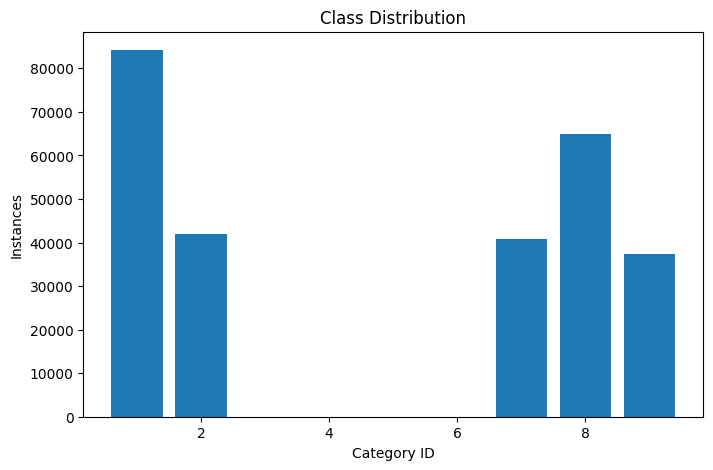

In [ ]:
import matplotlib.pyplot as plt

cats = list(counts.keys())
vals = list(counts.values())

plt.figure(figsize=(8,5))
plt.bar(cats, vals)
plt.xlabel("Category ID")
plt.ylabel("Instances")
plt.title("Class Distribution")
plt.show()

Moving the data to kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\n "username":"parrvvv",\n "key":"KGAT_33d4fb00e26362436c7321e157a284fb"\n \n}'}